SISTEM REKOMENDASI KOMODITAS PERTANIAN   
UAS DATA MINING 2026   
Nama: Lizam Sabit Mafaiz   
NIM: 24051214106   
Kelas: KDD 1  
Mata Kuliah: Data Mining

In [1]:
#Mengimpor Library Analisis Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
#Load Data
df = pd.read_csv('Crop_recommendation.csv')
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
# Mengecek jumlah baris, jumlah kolom, dan tipe data setiap atribut
print("Informasi Struktur Dataset")
df.info()

print("\nUkuran Dataset (Baris, Kolom)")
print(df.shape)

Informasi Struktur Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB

Ukuran Dataset (Baris, Kolom)
(2200, 8)


In [4]:
# Memeriksa apakah ada nilai kosong di setiap kolom
print("Jumlah Data Kosong per Kolom")
print(df.isnull().sum())

Jumlah Data Kosong per Kolom
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [5]:
# Melihat daftar tanaman unik yang ada di dataset beserta jumlah totalnya
print("Jumlah Jenis Tanaman Asli Bawaan Dataset")
print(f"Total jenis tanaman: {df['label'].nunique()}")

print("\nDaftar nama tanaman:")
print(df['label'].unique())

Jumlah Jenis Tanaman Asli Bawaan Dataset
Total jenis tanaman: 22

Daftar nama tanaman:
['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


In [6]:
# Menyaring dan Menerjemahkan Label Tanaman
# 1. Membuat daftar tanaman Indonesia yang ingin dipertahankan
tanaman_lokal = [
    'rice', 'maize', 'banana', 'mango', 'watermelon',
    'orange', 'papaya', 'coconut', 'coffee', 'grapes',
    'apple', 'pomegranate', 'muskmelon', 'mungbean'
]

# 2. Menyaring dataset hanya untuk tanaman yang dipilih
df_filtered = df[df['label'].isin(tanaman_lokal)].copy()

# 3. Membuat kamus untuk menerjemahkan nama Inggris ke Indonesia
kamus_terjemahan = {
    'rice': 'Padi', 'maize': 'Jagung', 'banana': 'Pisang',
    'mango': 'Mangga', 'watermelon': 'Semangka', 'orange': 'Jeruk',
    'papaya': 'Pepaya', 'coconut': 'Kelapa', 'coffee': 'Kopi',
    'grapes': 'Anggur', 'apple': 'Apel', 'pomegranate': 'Delima',
    'muskmelon': 'Melon', 'mungbean': 'Kacang Hijau'
}

# 4. Mengubah nama label di dataset menggunakan kamus
df_filtered['label'] = df_filtered['label'].map(kamus_terjemahan)

# 5. Mengecek hasil penyaringan
print("Hasil Penyaringan & Lokalisasi")
print(f"Jumlah baris setelah disaring: {df_filtered.shape[0]} baris")
print(f"Total jenis tanaman sekarang: {df_filtered['label'].nunique()} tanaman")
print("\nDaftar tanaman yang akan dipakai:")
print(df_filtered['label'].unique())

Hasil Penyaringan & Lokalisasi
Jumlah baris setelah disaring: 1400 baris
Total jenis tanaman sekarang: 14 tanaman

Daftar tanaman yang akan dipakai:
['Padi' 'Jagung' 'Kacang Hijau' 'Delima' 'Pisang' 'Mangga' 'Anggur'
 'Semangka' 'Melon' 'Apel' 'Jeruk' 'Pepaya' 'Kelapa' 'Kopi']


In [7]:
# Pembersihan Outlier Berbasis Kelas Tanaman
def hapus_outlier_per_tanaman(data, daftar_fitur):
    data_bersih_list = []

    for tanaman in data['label'].unique():
        df_tanaman = data[data['label'] == tanaman].copy()

        for fitur in daftar_fitur:
            Q1 = df_tanaman[fitur].quantile(0.25)
            Q3 = df_tanaman[fitur].quantile(0.75)
            IQR = Q3 - Q1

            batas_bawah = Q1 - 1.5 * IQR
            batas_atas = Q3 + 1.5 * IQR

            df_tanaman = df_tanaman[(df_tanaman[fitur] >= batas_bawah) & (df_tanaman[fitur] <= batas_atas)]

        data_bersih_list.append(df_tanaman)

    return pd.concat(data_bersih_list, ignore_index=True)

fitur_numerik = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

df_clean = hapus_outlier_per_tanaman(df_filtered, fitur_numerik)

print("Evaluasi Pembersihan Outlier")
print(f"Jumlah data sebelum dibersihkan outlier-nya: {df_filtered.shape[0]} baris")
print(f"Jumlah data setelah dibersihkan outlier-nya: {df_clean.shape[0]} baris")
print(f"Total baris data outlier yang berhasil dibuang : {df_filtered.shape[0] - df_clean.shape[0]} baris")

Evaluasi Pembersihan Outlier
Jumlah data sebelum dibersihkan outlier-nya: 1400 baris
Jumlah data setelah dibersihkan outlier-nya: 1400 baris
Total baris data outlier yang berhasil dibuang : 0 baris


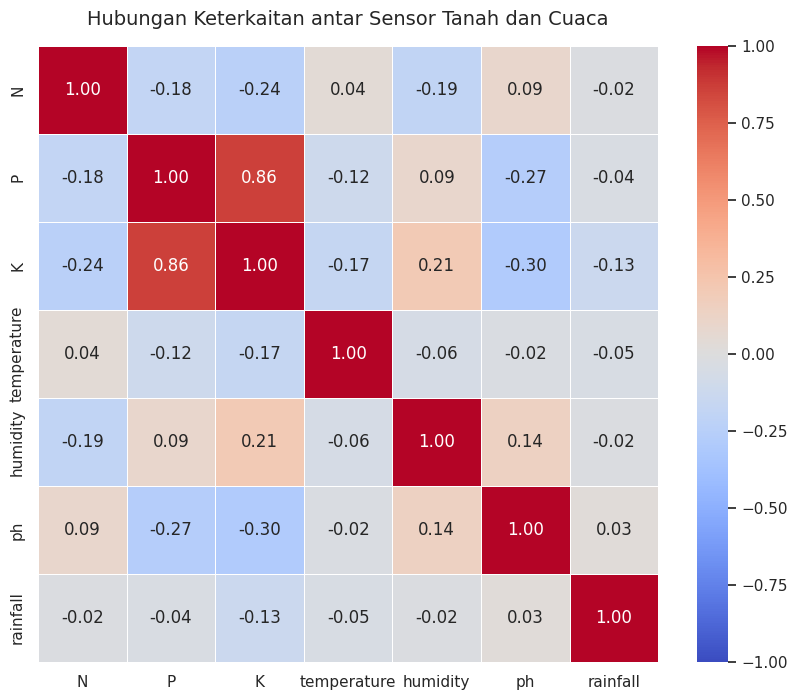


Pemeriksaan Pasangan Sensor Paling Berkaitan
Dua pasangan parameter yang memiliki hubungan paling kuat adalah:
- P dengan K: 0.8629
- K dengan P: 0.8629


In [8]:
# Hubungan Keterkaitan antar Sensor Tanah dan Cuaca
matriks_korelasi = df_clean[fitur_numerik].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    matriks_korelasi,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1, vmax=1
)

plt.title("Hubungan Keterkaitan antar Sensor Tanah dan Cuaca", fontsize=14, pad=15)
plt.show()

print("\nPemeriksaan Pasangan Sensor Paling Berkaitan")
korelasi_unstack = matriks_korelasi.abs().unstack()
korelasi_urut = korelasi_unstack.sort_values(ascending=False)
korelasi_tertinggi = korelasi_urut[korelasi_urut < 1.0].head(2)

print("Dua pasangan parameter yang memiliki hubungan paling kuat adalah:")
for index, nilai in korelasi_tertinggi.items():
    print(f"- {index[0]} dengan {index[1]}: {nilai:.4f}")

/tmp/ipykernel_3593/3976341993.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


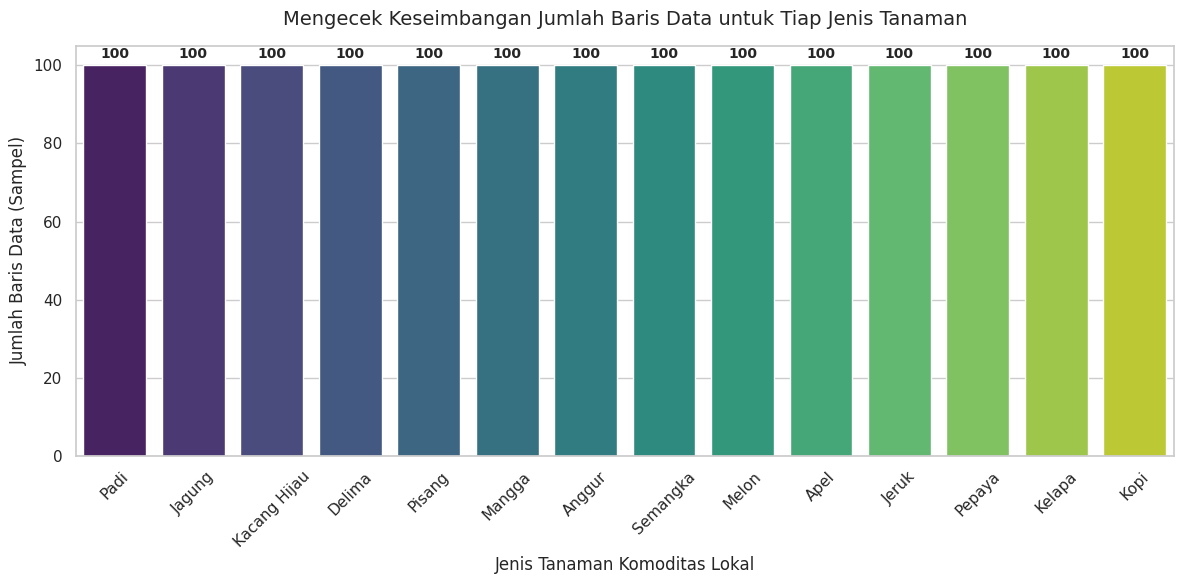


Ringkasan Keseimbangan Data
Jumlah sampel tanaman paling sedikit: 100 baris
Jumlah sampel tanaman paling banyak : 100 baris
Kesimpulan: Sebaran data masih sangat seimbang dan ideal untuk pemodelan Machine Learning.


In [9]:
# Mengecek Keseimbangan Jumlah Data per Tanaman
plt.figure(figsize=(12, 6))

urutan_tanaman = df_clean['label'].value_counts().index
sns.countplot(
    data=df_clean,
    x='label',
    order=urutan_tanaman,
    palette='viridis'
)

for i, count in enumerate(df_clean['label'].value_counts()):
    plt.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=10, weight='bold')

plt.title("Mengecek Keseimbangan Jumlah Baris Data untuk Tiap Jenis Tanaman", fontsize=14, pad=15)
plt.xlabel("Jenis Tanaman Komoditas Lokal", fontsize=12)
plt.ylabel("Jumlah Baris Data (Sampel)", fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

min_data = df_clean['label'].value_counts().min()
max_data = df_clean['label'].value_counts().max()
print("\nRingkasan Keseimbangan Data")
print(f"Jumlah sampel tanaman paling sedikit: {min_data} baris")
print(f"Jumlah sampel tanaman paling banyak : {max_data} baris")
print(f"Kesimpulan: Sebaran data masih sangat seimbang dan ideal untuk pemodelan Machine Learning.")

In [10]:
# Memisahkan Fitur (X) dan Target (y)
X = df_clean[fitur_numerik]

y = df_clean['label']

print("Pemisahan Atribut dan Target")
print(f"Ukuran Fitur (X) : {X.shape} -> (Jumlah baris, 7 kolom sensor)")
print(f"Ukuran Target (y) : {y.shape} -> (Jumlah baris target nama tanaman)")

Pemisahan Atribut dan Target
Ukuran Fitur (X) : (1400, 7) -> (Jumlah baris, 7 kolom sensor)
Ukuran Target (y) : (1400,) -> (Jumlah baris target nama tanaman)


In [11]:
# Mengubah Teks Tanaman Menjadi Angka (Label Encoding)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("Hasil Target Encoding")
for indeks, nama_asli in enumerate(le.classes_):
    print(f"Angka {indeks} = Tanaman {nama_asli}")

print(f"\n5 data target teratas setelah diubah: {y_encoded[:5]}")

Hasil Target Encoding
Angka 0 = Tanaman Anggur
Angka 1 = Tanaman Apel
Angka 2 = Tanaman Delima
Angka 3 = Tanaman Jagung
Angka 4 = Tanaman Jeruk
Angka 5 = Tanaman Kacang Hijau
Angka 6 = Tanaman Kelapa
Angka 7 = Tanaman Kopi
Angka 8 = Tanaman Mangga
Angka 9 = Tanaman Melon
Angka 10 = Tanaman Padi
Angka 11 = Tanaman Pepaya
Angka 12 = Tanaman Pisang
Angka 13 = Tanaman Semangka

5 data target teratas setelah diubah: [10 10 10 10 10]


In [12]:
# Menyetarakan Skala Angka Sensor (Feature Scaling)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=fitur_numerik)

print("Hasil Feature Scaling (StandardScaler)")
X_scaled_df.head(3)

Hasil Feature Scaling (StandardScaler)


,N,P,K,temperature,humidity,ph,rainfall
0,0.966156,-0.190384,-0.264190,-0.993267,0.023596,0.271548,1.610260
1,0.832453,0.212013,-0.298031,-0.823331,-0.099044,1.225601,2.015275
2,0.163939,0.136563,-0.247269,-0.587901,0.046769,2.655691,2.652313


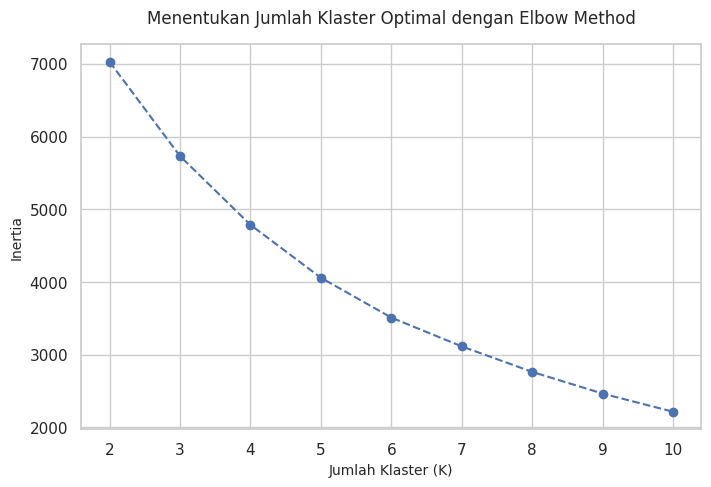

In [13]:
# Mencari Jumlah Klaster Terbaik Menggunakan Elbow Method
from sklearn.cluster import KMeans

inertia_values = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_values, marker='o', linestyle='--', color='b')
plt.title("Menentukan Jumlah Klaster Optimal dengan Elbow Method", fontsize=12, pad=15)
plt.xlabel("Jumlah Klaster (K)", fontsize=10)
plt.ylabel("Inertia", fontsize=10)
plt.xticks(K_range)
plt.grid(True)
plt.show()

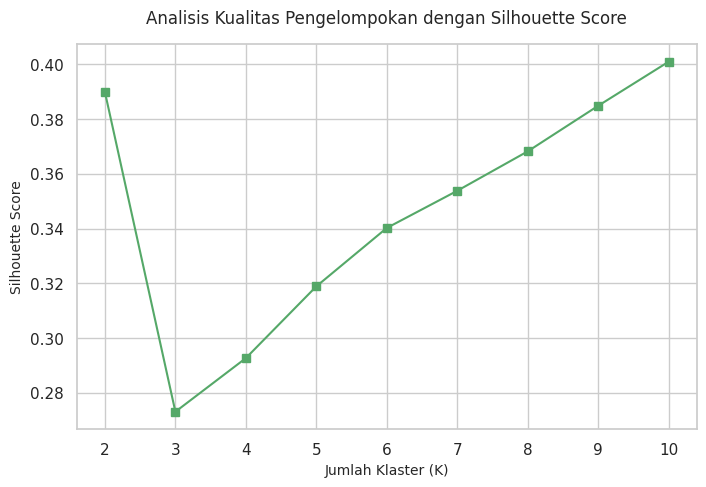


Kesimpulan
Jumlah klaster dengan Silhouette Score tertinggi adalah K = 10 (Skor: 0.4009)


In [14]:
# Validasi Jumlah Klaster Menggunakan Silhouette Score
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    klaster_labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, klaster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='s', linestyle='-', color='g')
plt.title("Analisis Kualitas Pengelompokan dengan Silhouette Score", fontsize=12, pad=15)
plt.xlabel("Jumlah Klaster (K)", fontsize=10)
plt.ylabel("Silhouette Score", fontsize=10)
plt.xticks(K_range)
plt.grid(True)
plt.show()

k_terbaik = K_range[np.argmax(silhouette_scores)]
skor_tertinggi = max(silhouette_scores)
print(f"\nKesimpulan")
print(f"Jumlah klaster dengan Silhouette Score tertinggi adalah K = {k_terbaik} (Skor: {skor_tertinggi:.4f})")

In [15]:
# Melatih Model Final K-Means dengan K = 5 (berdasarkan elbow method)
K_optimal = 5

kmeans_final = KMeans(n_clusters=K_optimal, random_state=42, n_init=10)
df_clean['cluster_lahan'] = kmeans_final.fit_predict(X_scaled)

print(f"Model K-Means Berhasil Dilatih Menggunakan Intervensi Manual (K={K_optimal}) ===")
print("Jumlah sampel lahan yang terbagi pada masing-masing dari 5 zona:")
print(df_clean['cluster_lahan'].value_counts().sort_index())

print("\nContoh 5 data teratas dengan kolom 'cluster_lahan' baru:")
df_clean[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'cluster_lahan']].head()

Model K-Means Berhasil Dilatih Menggunakan Intervensi Manual (K=5) ===
Jumlah sampel lahan yang terbagi pada masing-masing dari 5 zona:
cluster_lahan
0    334
1    239
2    200
3    293
4    334
Name: count, dtype: int64

Contoh 5 data teratas dengan kolom 'cluster_lahan' baru:


,N,P,K,temperature,humidity,ph,rainfall,cluster_lahan
0,90,42,43,20.879744,82.002744,6.502985,202.935536,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,1


1. TABEL NILAI RATA-RATA SENSOR PER ZONA LAHAN


,N,P,K,temperature,humidity,ph,rainfall
cluster_lahan,,,,,,,
0,21.12,28.82,25.31,24.79,89.69,6.70,90.64
1,52.14,39.27,38.64,27.35,89.03,6.33,207.64
2,21.99,133.38,200.00,23.24,87.10,5.98,91.13
3,65.71,34.54,26.70,26.42,57.67,6.27,113.19
4,96.57,40.69,49.53,27.88,86.21,6.31,62.25


------------------------------------------------------------


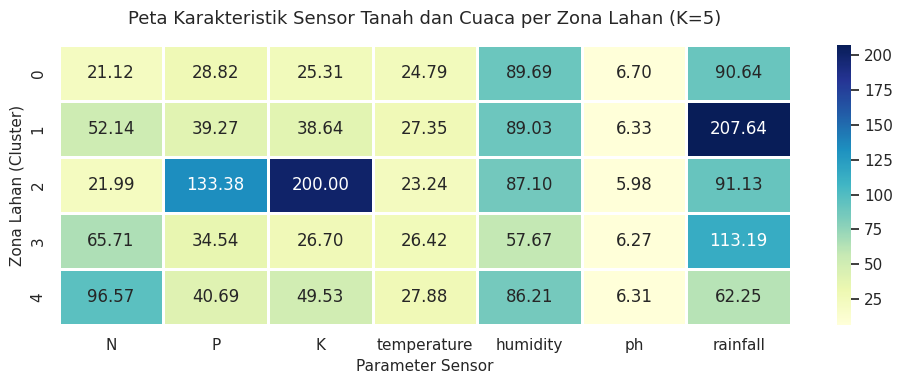

------------------------------------------------------------
2. SEBARAN KOMODITAS TANAMAN ASLI PADA TIAP ZONA LAHAN

ZONA LAHAN 0 (Total Lahan Terdeteksi: 334 Sampel Data)
  Top 3 Komoditas Tanaman Paling Dominan:
  * Kacang Hijau    : 100 data sampel (29.9%)
  * Delima          : 100 data sampel (29.9%)
  * Jeruk           : 100 data sampel (29.9%)

ZONA LAHAN 1 (Total Lahan Terdeteksi: 239 Sampel Data)
  Top 3 Komoditas Tanaman Paling Dominan:
  * Padi            : 100 data sampel (41.8%)
  * Kelapa          :  86 data sampel (36.0%)
  * Pepaya          :  53 data sampel (22.2%)

ZONA LAHAN 2 (Total Lahan Terdeteksi: 200 Sampel Data)
  Top 3 Komoditas Tanaman Paling Dominan:
  * Anggur          : 100 data sampel (50.0%)
  * Apel            : 100 data sampel (50.0%)

ZONA LAHAN 3 (Total Lahan Terdeteksi: 293 Sampel Data)
  Top 3 Komoditas Tanaman Paling Dominan:
  * Mangga          : 100 data sampel (34.1%)
  * Kopi            : 100 data sampel (34.1%)
  * Jagung          :  93 data s

In [16]:
# Analisis Karakteristik (Profiling) Tiap Zona Lahan
profil_cluster = df_clean.groupby('cluster_lahan')[fitur_numerik].mean()

print("1. TABEL NILAI RATA-RATA SENSOR PER ZONA LAHAN")
display(profil_cluster.round(2))
print("-" * 60)

plt.figure(figsize=(10, 4))
sns.heatmap(
    profil_cluster,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=1,
    cbar=True
)
plt.title("Peta Karakteristik Sensor Tanah dan Cuaca per Zona Lahan (K=5)", fontsize=13, pad=15)
plt.ylabel("Zona Lahan (Cluster)", fontsize=11)
plt.xlabel("Parameter Sensor", fontsize=11)
plt.tight_layout()
plt.show()
print("-" * 60)

print("2. SEBARAN KOMODITAS TANAMAN ASLI PADA TIAP ZONA LAHAN")
for cluster in sorted(df_clean['cluster_lahan'].unique()):
    top_tanaman = df_clean[df_clean['cluster_lahan'] == cluster]['label'].value_counts().head(3)
    total_data_zona = len(df_clean[df_clean['cluster_lahan'] == cluster])

    print(f"\nZONA LAHAN {cluster} (Total Lahan Terdeteksi: {total_data_zona} Sampel Data)")
    print("  Top 3 Komoditas Tanaman Paling Dominan:")

    for tanaman, jumlah in top_tanaman.items():
        persentase = (jumlah / total_data_zona) * 100
        print(f"  * {tanaman:<15} : {jumlah:>3} data sampel ({persentase:.1f}%)")

In [17]:
# Membuat kamus pemetaan berdasarkan hasil analisis data
kamus_nama_zona = {
    0: "Lahan Kering Alami & Tropis Hangat.",
    1: "Lahan Basah.",
    2: "Lahan Subur Dataran Tinggi.",
    3: "Lahan Moderat Dataran Rendah.",
    4: "Lahan Aluvial."
}

df_clean['nama_zona_lahan'] = df_clean['cluster_lahan'].map(kamus_nama_zona)

print("hasil transformasi:")
display(df_clean[['cluster_lahan', 'nama_zona_lahan', 'label']].head())

hasil transformasi:


,cluster_lahan,nama_zona_lahan,label
0,1,Lahan Basah.,Padi
1,1,Lahan Basah.,Padi
2,1,Lahan Basah.,Padi
3,1,Lahan Basah.,Padi
4,1,Lahan Basah.,Padi


In [18]:
# Membagi Dataset Menjadi Data Latih (Train Set) & Data Uji (Test Set)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [19]:
# Melatih Model Baseline (Gaussian Naive Bayes)
from sklearn.naive_bayes import GaussianNB

model_nb = GaussianNB()

model_nb.fit(X_train, y_train)

GaussianNB()

In [20]:
# Melatih Random Forest
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    min_samples_split=5,
    random_state=42
)

model_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=12, min_samples_split=5, n_estimators=150,
                       random_state=42)

In [21]:
# Melatih XGBoost
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

LANGKAH EVALUASI: SKOR AKURASI GLOBAL


,Model,Akurasi (%)
0,Naive Bayes (Baseline),100.0
1,Random Forest (Ensemble),100.0
2,XGBoost (Advanced),100.0


--------------------------------------------------


/tmp/ipykernel_3593/1134431344.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=skor_akurasi, x='Model', y='Akurasi (%)', palette='Set2')


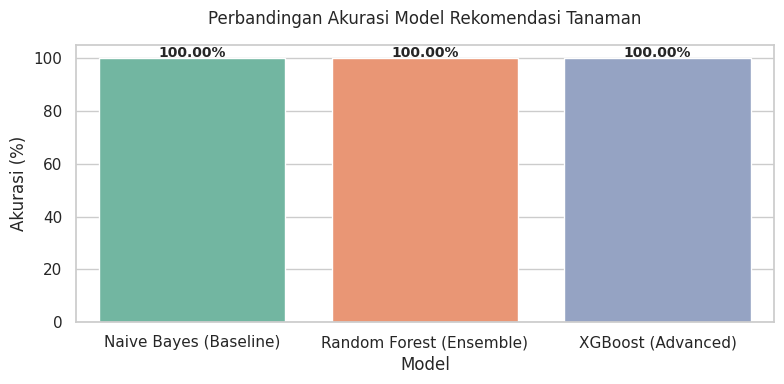

In [22]:
# Komparasi Akurasi Ketiga Model
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_nb = model_nb.predict(X_test)
y_pred_rf = model_rf.predict(X_test)
y_pred_xgb = model_xgb.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

skor_akurasi = pd.DataFrame({
    'Model': ['Naive Bayes (Baseline)', 'Random Forest (Ensemble)', 'XGBoost (Advanced)'],
    'Akurasi (%)': [acc_nb * 100, acc_rf * 100, acc_xgb * 100]
})

print("LANGKAH EVALUASI: SKOR AKURASI GLOBAL")
display(skor_akurasi.round(2))
print("-" * 50)

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=skor_akurasi, x='Model', y='Akurasi (%)', palette='Set2')
plt.title("Perbandingan Akurasi Model Rekomendasi Tanaman", fontsize=12, pad=15)
plt.ylim(0, 105)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 2),
                ha='center', va='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

In [23]:
# Performa per Komoditas Tanaman
from sklearn.metrics import classification_report

daftar_model = {
    'NAIVE BAYES (BASELINE)': y_pred_nb,
    'RANDOM FOREST (ENSEMBLE)': y_pred_rf,
    'XGBOOST (ADVANCED)': y_pred_xgb
}

for nama_model, hasil_prediksi in daftar_model.items():
    print(f" LAPORAN EVALUASI DETAIL: {nama_model}")
    print(classification_report(y_test, hasil_prediksi, target_names=le.classes_))
    print("\n" + "\n")

 LAPORAN EVALUASI DETAIL: NAIVE BAYES (BASELINE)
              precision    recall  f1-score   support

      Anggur       1.00      1.00      1.00        20
        Apel       1.00      1.00      1.00        20
      Delima       1.00      1.00      1.00        20
      Jagung       1.00      1.00      1.00        20
       Jeruk       1.00      1.00      1.00        20
Kacang Hijau       1.00      1.00      1.00        20
      Kelapa       1.00      1.00      1.00        20
        Kopi       1.00      1.00      1.00        20
      Mangga       1.00      1.00      1.00        20
       Melon       1.00      1.00      1.00        20
        Padi       1.00      1.00      1.00        20
      Pepaya       1.00      1.00      1.00        20
      Pisang       1.00      1.00      1.00        20
    Semangka       1.00      1.00      1.00        20

    accuracy                           1.00       280
   macro avg       1.00      1.00      1.00       280
weighted avg       1.00      1.

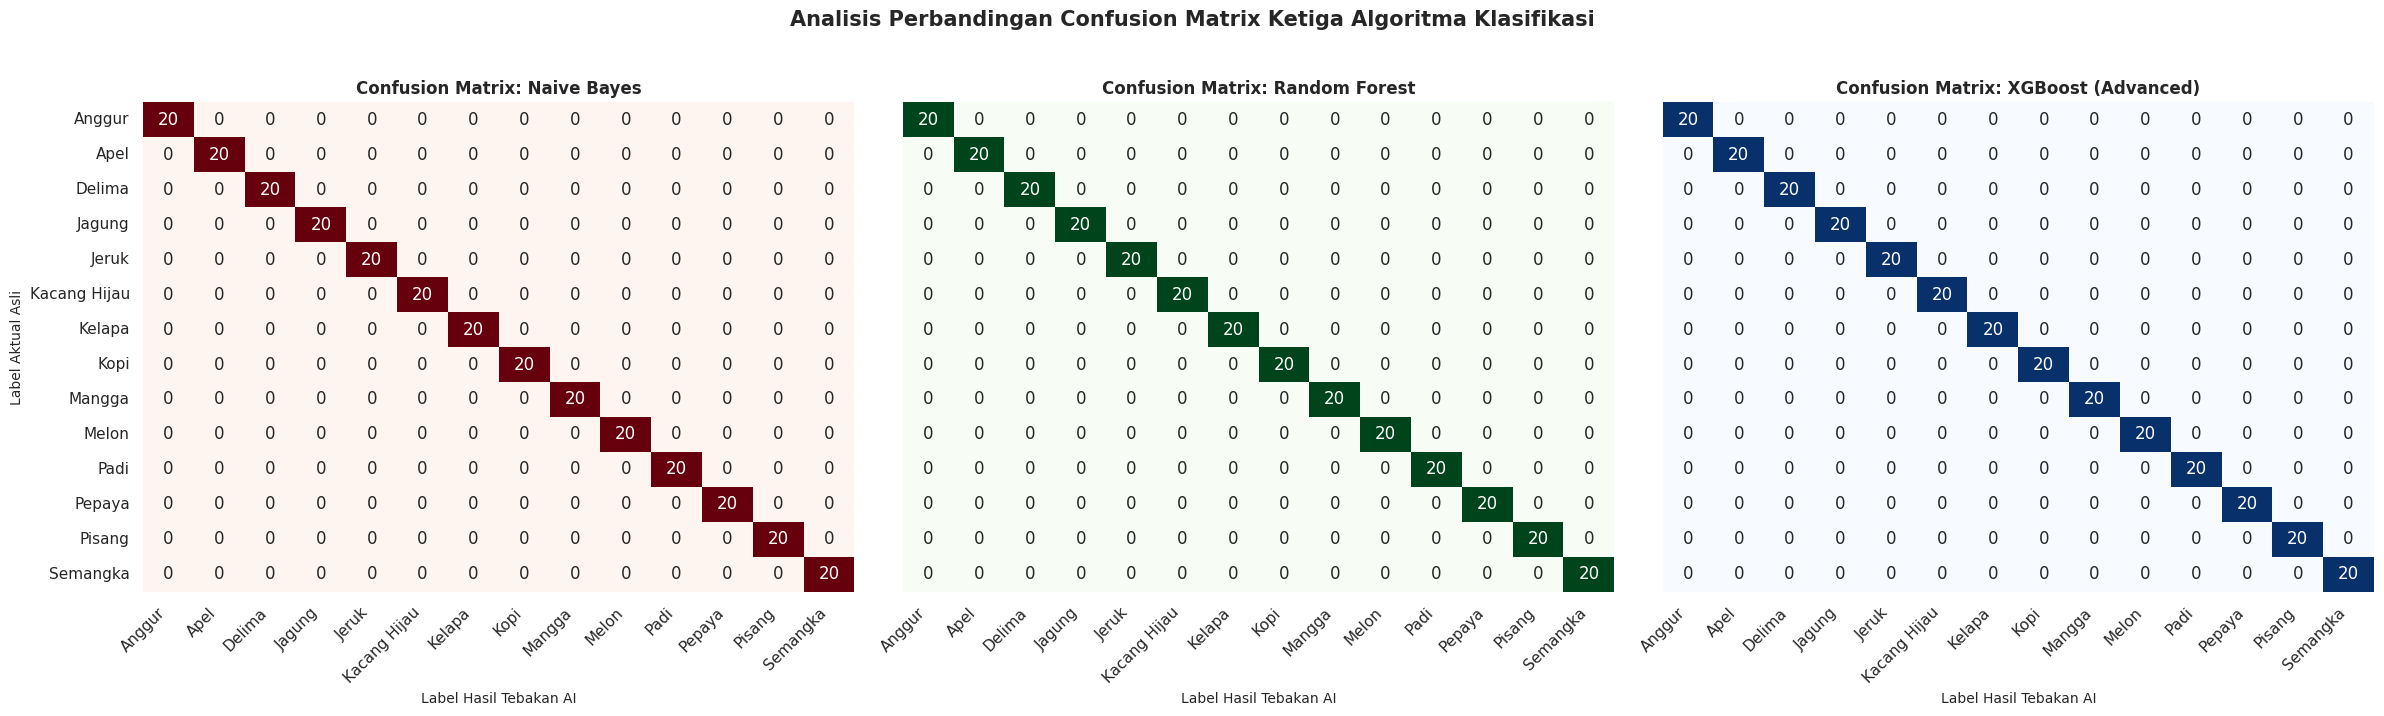

In [24]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_, cbar=False)
axes[0].set_title("Confusion Matrix: Naive Bayes", fontsize=12, weight='bold')
axes[0].set_ylabel("Label Aktual Asli", fontsize=10)
axes[0].set_xlabel("Label Hasil Tebakan AI", fontsize=10)
axes[0].set_xticklabels(le.classes_, rotation=45, ha='right')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_, cbar=False)
axes[1].set_title("Confusion Matrix: Random Forest", fontsize=12, weight='bold')
axes[1].set_xlabel("Label Hasil Tebakan AI", fontsize=10)
axes[1].set_xticklabels(le.classes_, rotation=45, ha='right')
axes[1].set_yticklabels([])

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=le.classes_, yticklabels=le.classes_, cbar=False)
axes[2].set_title("Confusion Matrix: XGBoost (Advanced)", fontsize=12, weight='bold')
axes[2].set_xlabel("Label Hasil Tebakan AI", fontsize=10)
axes[2].set_xticklabels(le.classes_, rotation=45, ha='right')
axes[2].set_yticklabels([])

plt.suptitle("Analisis Perbandingan Confusion Matrix Ketiga Algoritma Klasifikasi", fontsize=15, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [25]:
# Save
import pickle
komponen_ai = {
    'model_klasifikasi': model_xgb,
    'model_clustering': kmeans_final,
    'scaler': scaler,
    'encoder': le,
    'kamus_zona': kamus_nama_zona
}

nama_file = 'model_rekomendasi_tanaman.pkl'
with open(nama_file, 'wb') as file:
    pickle.dump(komponen_ai, file)

print(f"FILE '{nama_file}'")

FILE 'model_rekomendasi_tanaman.pkl'


In [26]:
df_export = df_clean.copy()

kolom_ekspor = [
    'N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall',
    'label', 'cluster_lahan', 'nama_zona_lahan'
]
df_export = df_export[kolom_ekspor]

df_export.to_csv('Crop_recommendation_clean.csv', index=False)